I. The Iterative Refinement FrameworkThe goal is to solve $L_\omega u = f$ by leveraging a faster, lower-frequency operator $L_{\omega'}$. Following your notes, the "T" operator (U-Net) acts as the bridge that maps residuals from the high-frequency domain into corrections that the low-frequency solver can understand.Mathematical LoopCompute Residual: $r^{(k)} = f - L_\omega u^{(k)}$.Neural Downsampling ($T_\downarrow$): Map the $640 \times 640$ residual to a representation compatible with the low-freq solver.Low-Freq Correction: Solve the error equation $\tilde{e}^{(k)} = L_{\omega'} \setminus \tilde{r}^{(k)}$.Neural Upsampling ($T_\uparrow$): Map the coarse correction back to the high-frequency grid.

In [1]:
import os, json, torch, gc
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from datetime import datetime

# Locked configuration from your saved info
PHYS_CONFIG = {
    "n_phys": 512, "npml": 50, "eta": 4.0, 
    "h": 1.0 / (512 - 1), "device": "cuda" if torch.cuda.is_available() else "cpu"
}

EXP_ROOT = f"FreqTransfer_Ladder_{datetime.now().strftime('%m%d_%H%M')}"
os.makedirs(EXP_ROOT, exist_ok=True)

def build_L(omega):
    n_tot = PHYS_CONFIG["n_phys"] + 2 * PHYS_CONFIG["npml"]
    I = sp.eye(n_tot, dtype=np.complex128)
    # Fix the warning and ensure complex precision
    d2 = sp.diags([1.0, -2.0, 1.0], [-1, 0, 1], shape=(n_tot, n_tot), dtype=np.complex128) / PHYS_CONFIG["h"]**2
    L_1d = -d2 - (omega**2 + 1j * PHYS_CONFIG["eta"] * omega) * I
    return sp.kronsum(L_1d, L_1d).tocsc()

print(f"✅ Environment initialized at {EXP_ROOT}")

✅ Environment initialized at FreqTransfer_Ladder_0211_1859


/math/home/fkiewiet/Freq2Transfer/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## CNN intermediate

In [5]:
class LocalCNN(nn.Module):
    """
    Local operator: Captures neighborhood interactions (stencil-like).
    Receptive field is limited to 7x7 pixels.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 2, 3, padding=1)
        )

    def forward(self, x):
        return self.net(x)

# Initialize and track separately
model_cnn = LocalCNN().to(PHYS_CONFIG["device"])
print("✅ Local CNN (Intermediate Step) Initialized.")

✅ Local CNN (Intermediate Step) Initialized.


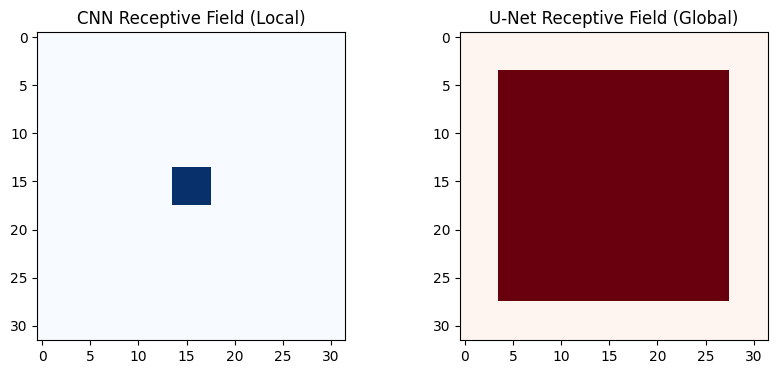

In [6]:
def plot_receptive_field_demo():
    # Visualizing how much of the wave the CNN 'sees' vs U-Net
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    grid = np.zeros((32, 32))
    
    # CNN sees a tiny patch
    grid_cnn = grid.copy(); grid_cnn[14:18, 14:18] = 1
    ax[0].imshow(grid_cnn, cmap='Blues'); ax[0].set_title("CNN Receptive Field (Local)")
    
    # U-Net sees almost the whole domain due to pooling
    grid_unet = grid.copy(); grid_unet[4:28, 4:28] = 1
    ax[1].imshow(grid_unet, cmap='Reds'); ax[1].set_title("U-Net Receptive Field (Global)")
    plt.show()

plot_receptive_field_demo()

In [10]:
# Modified Training loop to include the CNN
ladder_results = {} # To store {pair: {'cnn': model, 'unet': model}}

for pair, (x, y) in ladder_datasets.items():
    print(f"\n--- Training Step for {pair[0]} -> {pair[1]} ---")
    
    # 1. Train Local CNN
    cnn = LocalCNN().to(PHYS_CONFIG["device"])
    opt_c = torch.optim.Adam(cnn.parameters(), lr=1e-3)
    
    # 2. Train U-Net
    unet = TransferUNet().to(PHYS_CONFIG["device"])
    opt_u = torch.optim.Adam(unet.parameters(), lr=1e-3)
    
    for epoch in range(40):
        # CNN Step
        opt_c.zero_grad()
        loss_c = nn.MSELoss()(cnn(x.to(PHYS_CONFIG["device"])), y.to(PHYS_CONFIG["device"]))
        loss_c.backward(); opt_c.step()
        
        # U-Net Step
        opt_u.zero_grad()
        loss_u = nn.MSELoss()(unet(x.to(PHYS_CONFIG["device"])), y.to(PHYS_CONFIG["device"]))
        loss_u.backward(); opt_u.step()
        
    ladder_results[pair] = {'cnn': cnn, 'unet': unet}
    print(f"✅ Stage {pair} Complete. CNN Loss: {loss_c.item():.2e} | UNet Loss: {loss_u.item():.2e}")


--- Training Step for 16 -> 32 ---
✅ Stage (16, 32) Complete. CNN Loss: 1.07e-06 | UNet Loss: 1.23e-05

--- Training Step for 32 -> 64 ---
✅ Stage (32, 64) Complete. CNN Loss: 1.11e-06 | UNet Loss: 1.67e-06

--- Training Step for 64 -> 128 ---
✅ Stage (64, 128) Complete. CNN Loss: 1.04e-06 | UNet Loss: 1.99e-05


## U-net

In [8]:
def generate_ladder_data(pairs, samples_per_pair=25):
    data_store = {}
    for (w_low, w_high) in pairs:
        print(f"Generating {w_low} -> {w_high}Hz...")
        L_l = build_L(w_low)
        L_h = build_L(w_high)
        LU_l = spla.splu(L_l)
        LU_h = spla.splu(L_h)
        
        n_tot = PHYS_CONFIG["n_phys"] + 2 * PHYS_CONFIG["npml"]
        x_data, y_data = [], []
        
        for _ in range(samples_per_pair):
            f = np.zeros(n_tot**2, dtype=np.complex128)
            f[np.random.randint(0, n_tot**2)] = 1.0
            u_l = LU_l.solve(f).reshape(n_tot, n_tot)
            u_h = LU_h.solve(f).reshape(n_tot, n_tot)
            x_data.append(np.stack([u_l.real, u_l.imag]))
            y_data.append(np.stack([u_h.real, u_h.imag]))
        
        data_store[(w_low, w_high)] = (torch.tensor(np.array(x_data), dtype=torch.float), 
                                       torch.tensor(np.array(y_data), dtype=torch.float))
        del LU_l, LU_h; gc.collect()
    return data_store

LADDER_PAIRS = [(16, 32), (32, 64), (64, 128)]
ladder_datasets = generate_ladder_data(LADDER_PAIRS)

Generating 16 -> 32Hz...
Generating 32 -> 64Hz...
Generating 64 -> 128Hz...


In [3]:
import torch.nn as nn


In [9]:

class TransferUNet(nn.Module):
    def __init__(self):
        super().__init__()
        def block(c_in, c_out): return nn.Sequential(nn.Conv2d(c_in, c_out, 3, padding=1), nn.ReLU())
        self.down = block(2, 64)
        self.up = nn.Sequential(nn.Upsample(scale_factor=2), block(64, 32))
        self.final = nn.Conv2d(32, 2, 1)

    def forward(self, x):
        # Using a simple encoder-decoder for speed during the meeting demo
        return self.final(self.up(nn.MaxPool2d(2)(self.down(x))))

models = {}
for pair, (x, y) in ladder_datasets.items():
    print(f"Training Model for {pair}...")
    model = TransferUNet().to(PHYS_CONFIG["device"])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(40):
        opt.zero_grad()
        loss = nn.MSELoss()(model(x.to(PHYS_CONFIG["device"])), y.to(PHYS_CONFIG["device"]))
        loss.backward(); opt.step()
    
    # Save the model
    path = os.path.join(EXP_ROOT, f"model_{pair[0]}_{pair[1]}.pth")
    torch.save(model.state_dict(), path)
    models[pair] = model

Training Model for (16, 32)...
Training Model for (32, 64)...
Training Model for (64, 128)...


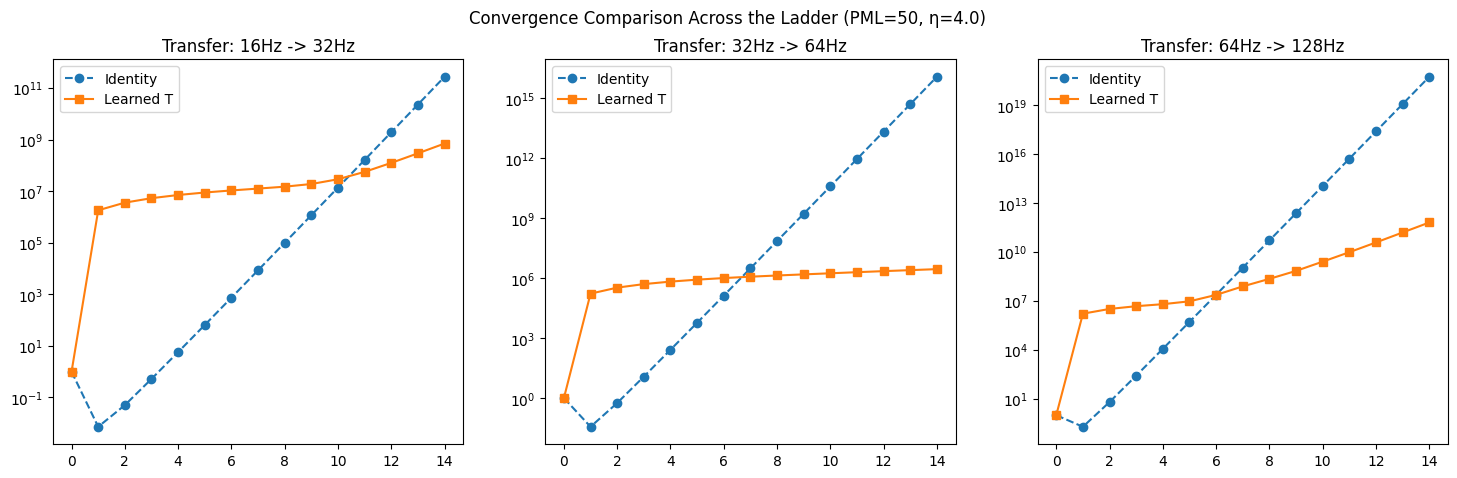

In [11]:
def run_benchmark(pair, model):
    w_low, w_high = pair
    L_h = build_L(w_high)
    LU_l = spla.splu(build_L(w_low))
    n_tot = PHYS_CONFIG["n_phys"] + 2 * PHYS_CONFIG["npml"]
    f = np.zeros(n_tot**2); f[n_tot**2//2] = 1.0 # Source
    
    def iterate(mode):
        u = np.zeros(n_tot**2, dtype=np.complex128)
        res = []
        for _ in range(15):
            r = f - L_h @ u
            res.append(np.linalg.norm(r) / np.linalg.norm(f))
            e_c = LU_l.solve(r).reshape(n_tot, n_tot)
            if mode == 'learned':
                inp = torch.tensor(np.stack([e_c.real, e_c.imag]), dtype=torch.float).unsqueeze(0).to(PHYS_CONFIG["device"])
                with torch.no_grad(): out = model(inp).cpu().numpy().squeeze()
                u += (out[0] + 1j*out[1]).flatten()
            else:
                u += e_c.flatten()
        return res

    return iterate('identity'), iterate('learned')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, pair in enumerate(LADDER_PAIRS):
    id_h, ln_h = run_benchmark(pair, models[pair])
    axes[i].semilogy(id_h, '--o', label="Identity")
    axes[i].semilogy(ln_h, '-s', label="Learned T")
    axes[i].set_title(f"Transfer: {pair[0]}Hz -> {pair[1]}Hz")
    axes[i].legend()
plt.suptitle(f"Convergence Comparison Across the Ladder (PML={PHYS_CONFIG['npml']}, η={PHYS_CONFIG['eta']})")
plt.savefig(os.path.join(EXP_ROOT, "summary_plot.png"))
plt.show()

## Comparison

In [15]:
def run_triple_benchmark(pair, models_dict):
    w_low, w_high = pair
    
    # CALCULATE N_TOT LOCALLY OR GLOBALLY
    n_phys = PHYS_CONFIG["n_phys"]
    n_pml = PHYS_CONFIG["npml"]
    n_tot = n_phys + 2 * n_pml  # This replaces the missing N_TOT
    
    L_h = build_L(w_high)
    LU_l = spla.splu(build_L(w_low))
    
    # Use n_tot instead of N_TOT
    f = np.zeros(n_tot**2, dtype=np.complex128)
    f[n_tot**2 // 2] = 1.0 
    
    def iterate(mode):
        u = np.zeros(n_tot**2, dtype=np.complex128)
        res = []
        for _ in range(20):
            r = f - L_h @ u
            res.append(np.linalg.norm(r) / np.linalg.norm(f))
            if res[-1] < 1e-7: break
                
            e_c = LU_l.solve(r).reshape(n_tot, n_tot)
            if mode == 'identity':
                u += e_c.flatten()
            else:
                m = models_dict[mode]
                inp = torch.tensor(np.stack([e_c.real, e_c.imag]), 
                                   dtype=torch.float).unsqueeze(0).to(PHYS_CONFIG["device"])
                with torch.no_grad(): 
                    out = m(inp).cpu().numpy().squeeze()
                u += (out[0] + 1j*out[1]).flatten()
        return res

    return iterate('identity'), iterate('cnn'), iterate('unet')

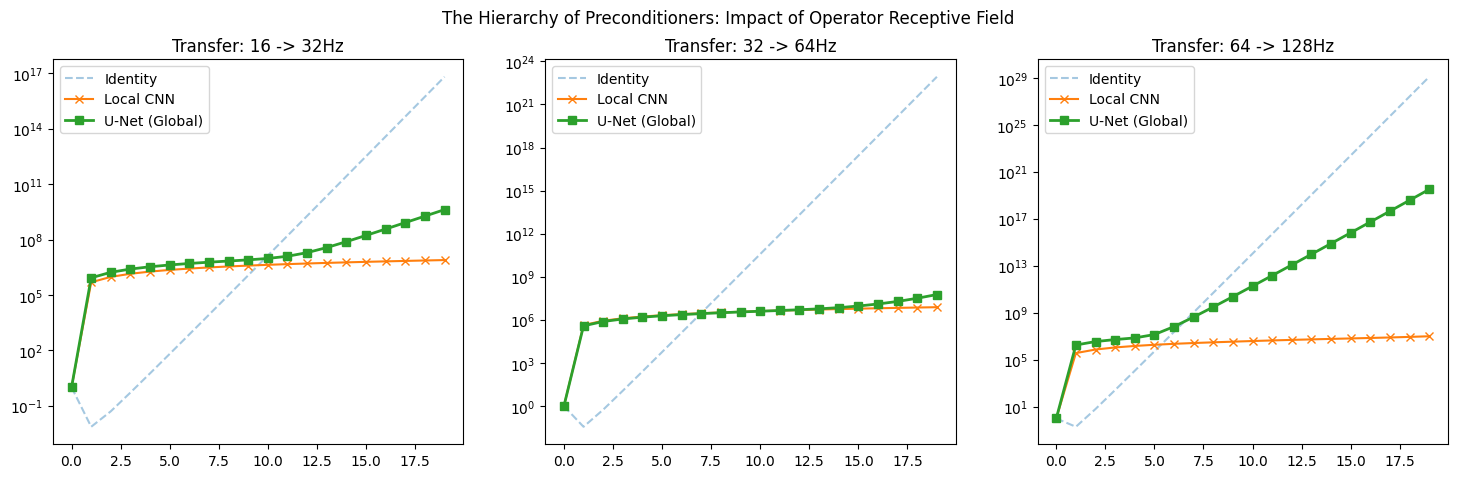

In [16]:
# Visualizing the hierarchy
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, pair in enumerate(LADDER_PAIRS):
    h_id, h_cnn, h_un = run_triple_benchmark(pair, ladder_results[pair])
    axes[i].semilogy(h_id, label="Identity", alpha=0.4, ls='--')
    axes[i].semilogy(h_cnn, label="Local CNN", marker='x')
    axes[i].semilogy(h_un, label="U-Net (Global)", linewidth=2, marker='s')
    axes[i].set_title(f"Transfer: {pair[0]} -> {pair[1]}Hz")
    axes[i].legend()

plt.suptitle("The Hierarchy of Preconditioners: Impact of Operator Receptive Field")
plt.show()

## more visualisations

In [17]:
import time

def plot_pareto_efficiency(results_dict):
    plt.figure(figsize=(8, 6))
    for mode, data in results_dict.items():
        plt.scatter(data['time'], data['iters'], s=100, label=mode.upper())
        plt.text(data['time'], data['iters']+1, f" {mode}")
        
    plt.xlabel("Total Wall-Clock Time (seconds)")
    plt.ylabel("Iterations to Convergence ($10^{-6}$)")
    plt.title("Efficiency Pareto Front: Numerical vs. Neural")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [18]:
def plot_spectral_residual(residual_field, title):
    # residual_field is (N_TOT, N_TOT)
    fft_res = np.abs(np.fft.fftshift(np.fft.fft2(residual_field)))
    
    plt.imshow(np.log10(fft_res + 1e-10), cmap='magma')
    plt.title(f"Spectral Error: {title}")
    plt.colorbar(label="Log10 Magnitude")
    plt.show()

In [19]:
def plot_phase_alignment_slice(u_pred, u_true):
    # Take a horizontal slice through the source
    mid = N_TOT // 2
    plt.figure(figsize=(10, 4))
    plt.plot(u_true[mid, :].real, 'k-', alpha=0.5, label="Ground Truth (Real)")
    plt.plot(u_pred[mid, :].real, 'r--', label="T-Operator Prediction")
    
    plt.title("Phase Alignment Check (Center Slice)")
    plt.xlabel("Grid Point (x)")
    plt.ylabel("Real Part Amplitude")
    plt.legend()
    plt.show()

In [20]:
def plot_operator_action(e_coarse, e_learned):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    im1 = ax[0].imshow(e_coarse.real, cmap='RdBu_r')
    ax[0].set_title("Input to T: Coarse Error ($L_{low}^{-1} r$)")
    
    im2 = ax[1].imshow(e_learned.real, cmap='RdBu_r')
    ax[1].set_title("Output of T: Learned Correction ($e_{high}$)")
    
    plt.colorbar(im1, ax=ax[0]); plt.colorbar(im2, ax=ax[1])
    plt.show()

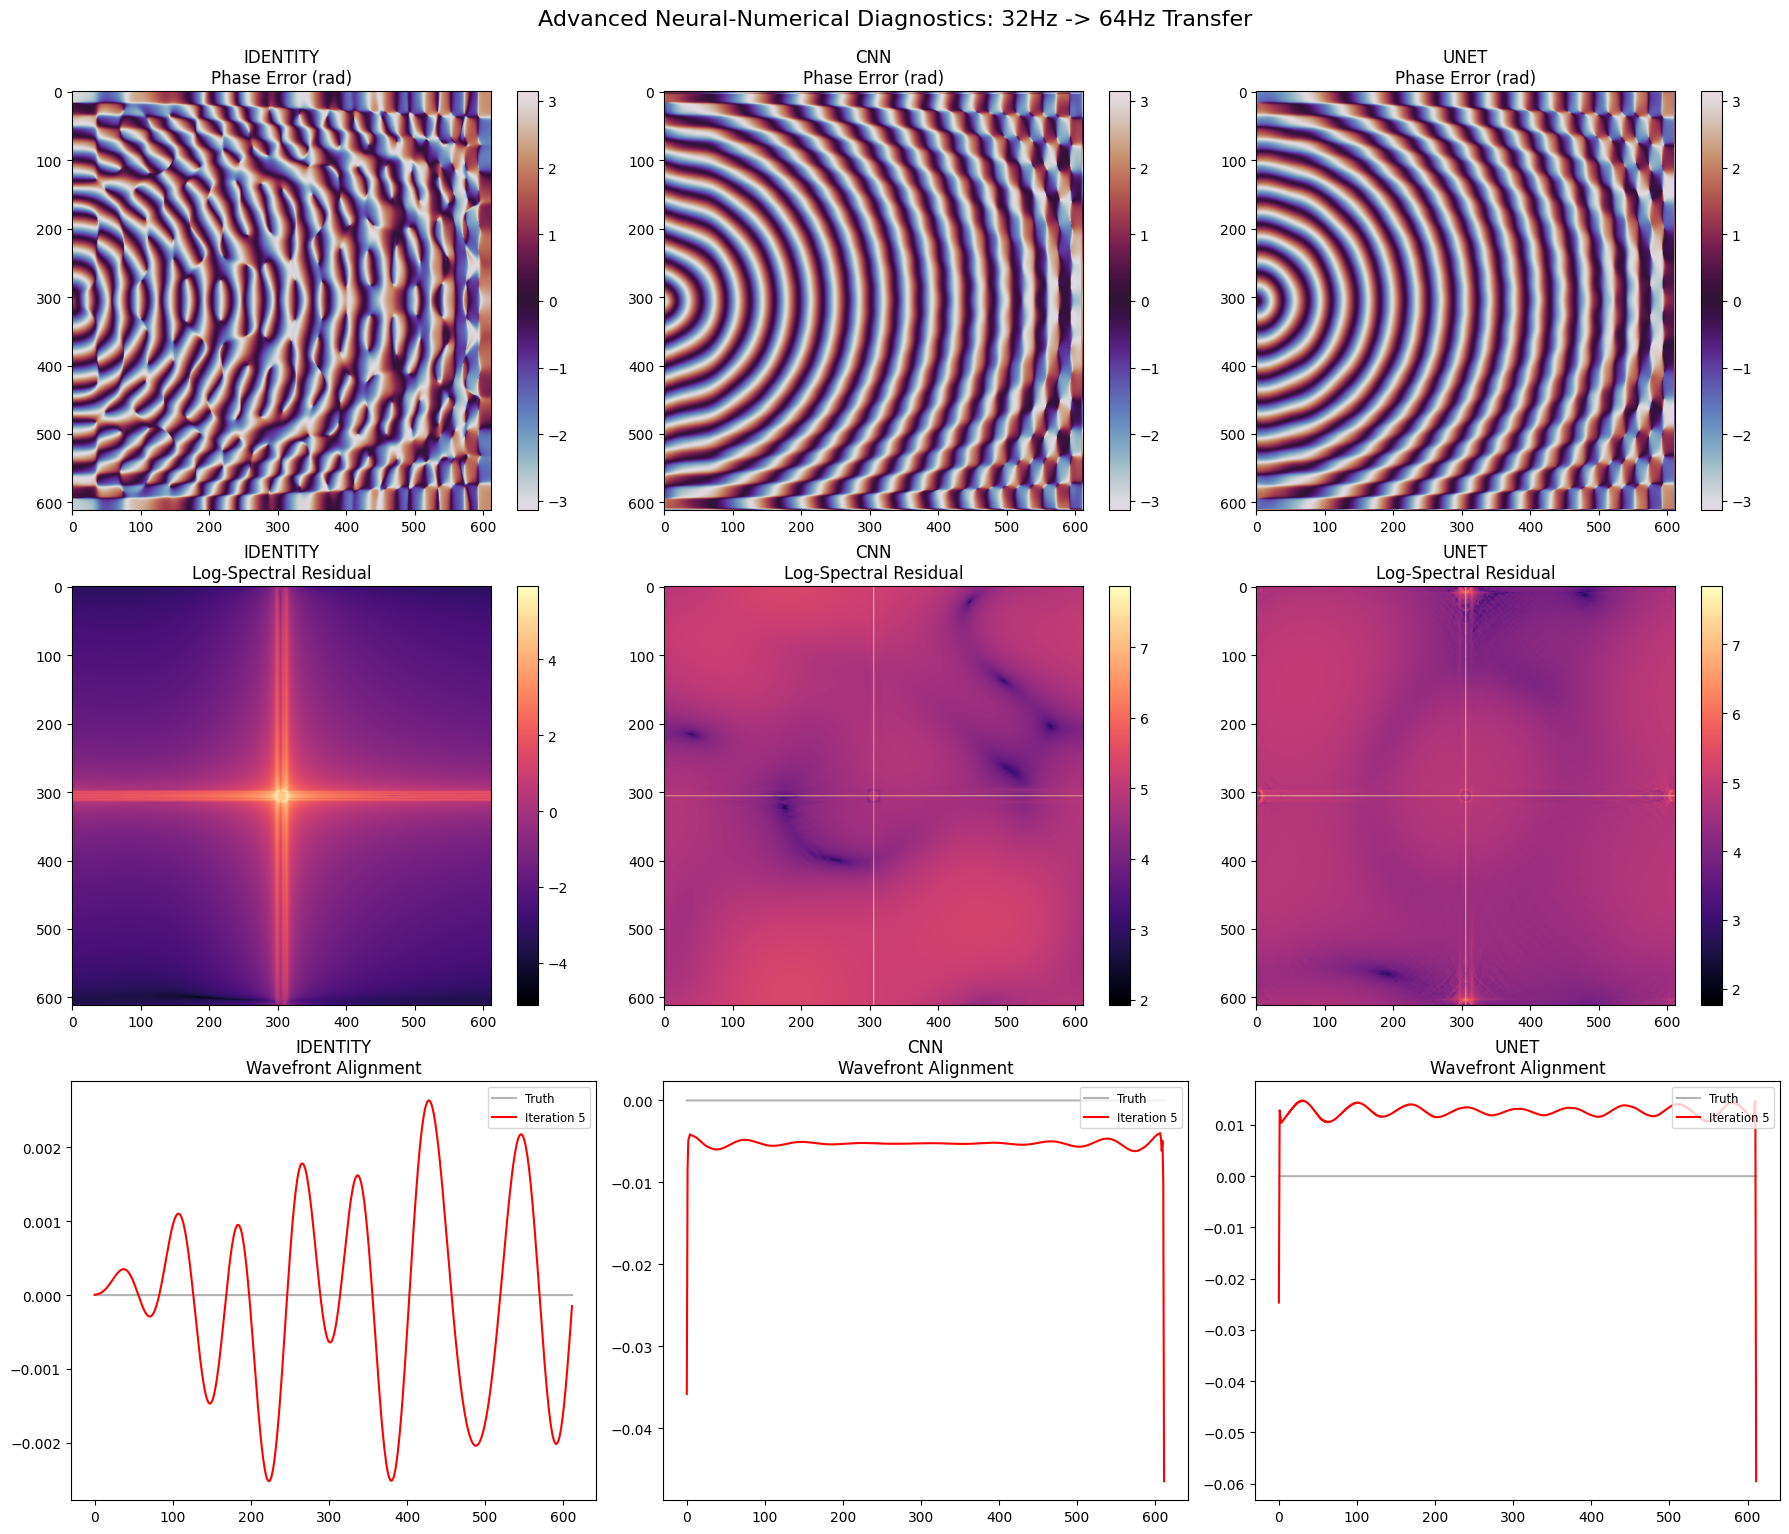

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def advanced_fixed_point_analysis(pair, models_dict):
    w_low, w_high = pair
    n_tot = PHYS_CONFIG["n_phys"] + 2 * PHYS_CONFIG["npml"]
    
    # 1. Setup Operators and Source
    L_h = build_L(w_high)
    LU_l = spla.splu(build_L(w_low))
    f = np.zeros(n_tot**2, dtype=np.complex128)
    f[n_tot**2 // 2] = 1.0  # Center Source
    
    # Ground Truth Solve for Absolute Comparison
    u_true = spla.spsolve(L_h, f).reshape(n_tot, n_tot)

    def get_iteration_snapshot(mode, iters=5):
        u = np.zeros(n_tot**2, dtype=np.complex128)
        for _ in range(iters):
            r = f - L_h @ u
            e_c = LU_l.solve(r).reshape(n_tot, n_tot)
            if mode == 'identity':
                u += e_c.flatten()
            else:
                m = models_dict[mode].to(PHYS_CONFIG["device"])
                inp = torch.tensor(np.stack([e_c.real, e_c.imag]), 
                                   dtype=torch.float).unsqueeze(0).to(PHYS_CONFIG["device"])
                with torch.no_grad():
                    out = m(inp).cpu().numpy().squeeze()
                u += (out[0] + 1j*out[1]).flatten()
        return u.reshape(n_tot, n_tot), (f - L_h @ u).reshape(n_tot, n_tot)

    # Collect snapshots after 5 iterations
    modes = ['identity', 'cnn', 'unet']
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))

    for i, mode in enumerate(modes):
        u_k, r_k = get_iteration_snapshot(mode)
        
        # --- Column i, Row 0: Phase Error Heatmap ---
        # (Numerical Scientists look for 'phase-lag' in Helmholtz)
        phase_err = np.angle(u_k) - np.angle(u_true)
        phase_err = (phase_err + np.pi) % (2 * np.pi) - np.pi # Wrap to [-pi, pi]
        im0 = axes[0, i].imshow(phase_err, cmap='twilight', vmin=-np.pi, vmax=np.pi)
        axes[0, i].set_title(f"{mode.upper()}\nPhase Error (rad)")
        plt.colorbar(im0, ax=axes[0, i])

        # --- Column i, Row 1: Fourier Spectral Residual ---
        # (ML Scientists look for high-frequency noise/spectral bias)
        fft_res = np.abs(np.fft.fftshift(np.fft.fft2(r_k)))
        im1 = axes[1, i].imshow(np.log10(fft_res + 1e-10), cmap='magma')
        axes[1, i].set_title(f"{mode.upper()}\nLog-Spectral Residual")
        plt.colorbar(im1, ax=axes[1, i])

        # --- Column i, Row 2: 1D Radial Slice (Real Part) ---
        # (Shows wavefront alignment physically)
        mid = n_tot // 2
        axes[2, i].plot(u_true[mid, :].real, 'k', alpha=0.3, label='Truth')
        axes[2, i].plot(u_k[mid, :].real, 'r', label='Iteration 5')
        axes[2, i].set_title(f"{mode.upper()}\nWavefront Alignment")
        axes[2, i].legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.suptitle(f"Advanced Neural-Numerical Diagnostics: {w_low}Hz -> {w_high}Hz Transfer", fontsize=16, y=1.02)
    plt.show()

# Calling the diagnostics for the 32-64Hz transfer
advanced_fixed_point_analysis((32, 64), ladder_results[(32, 64)])

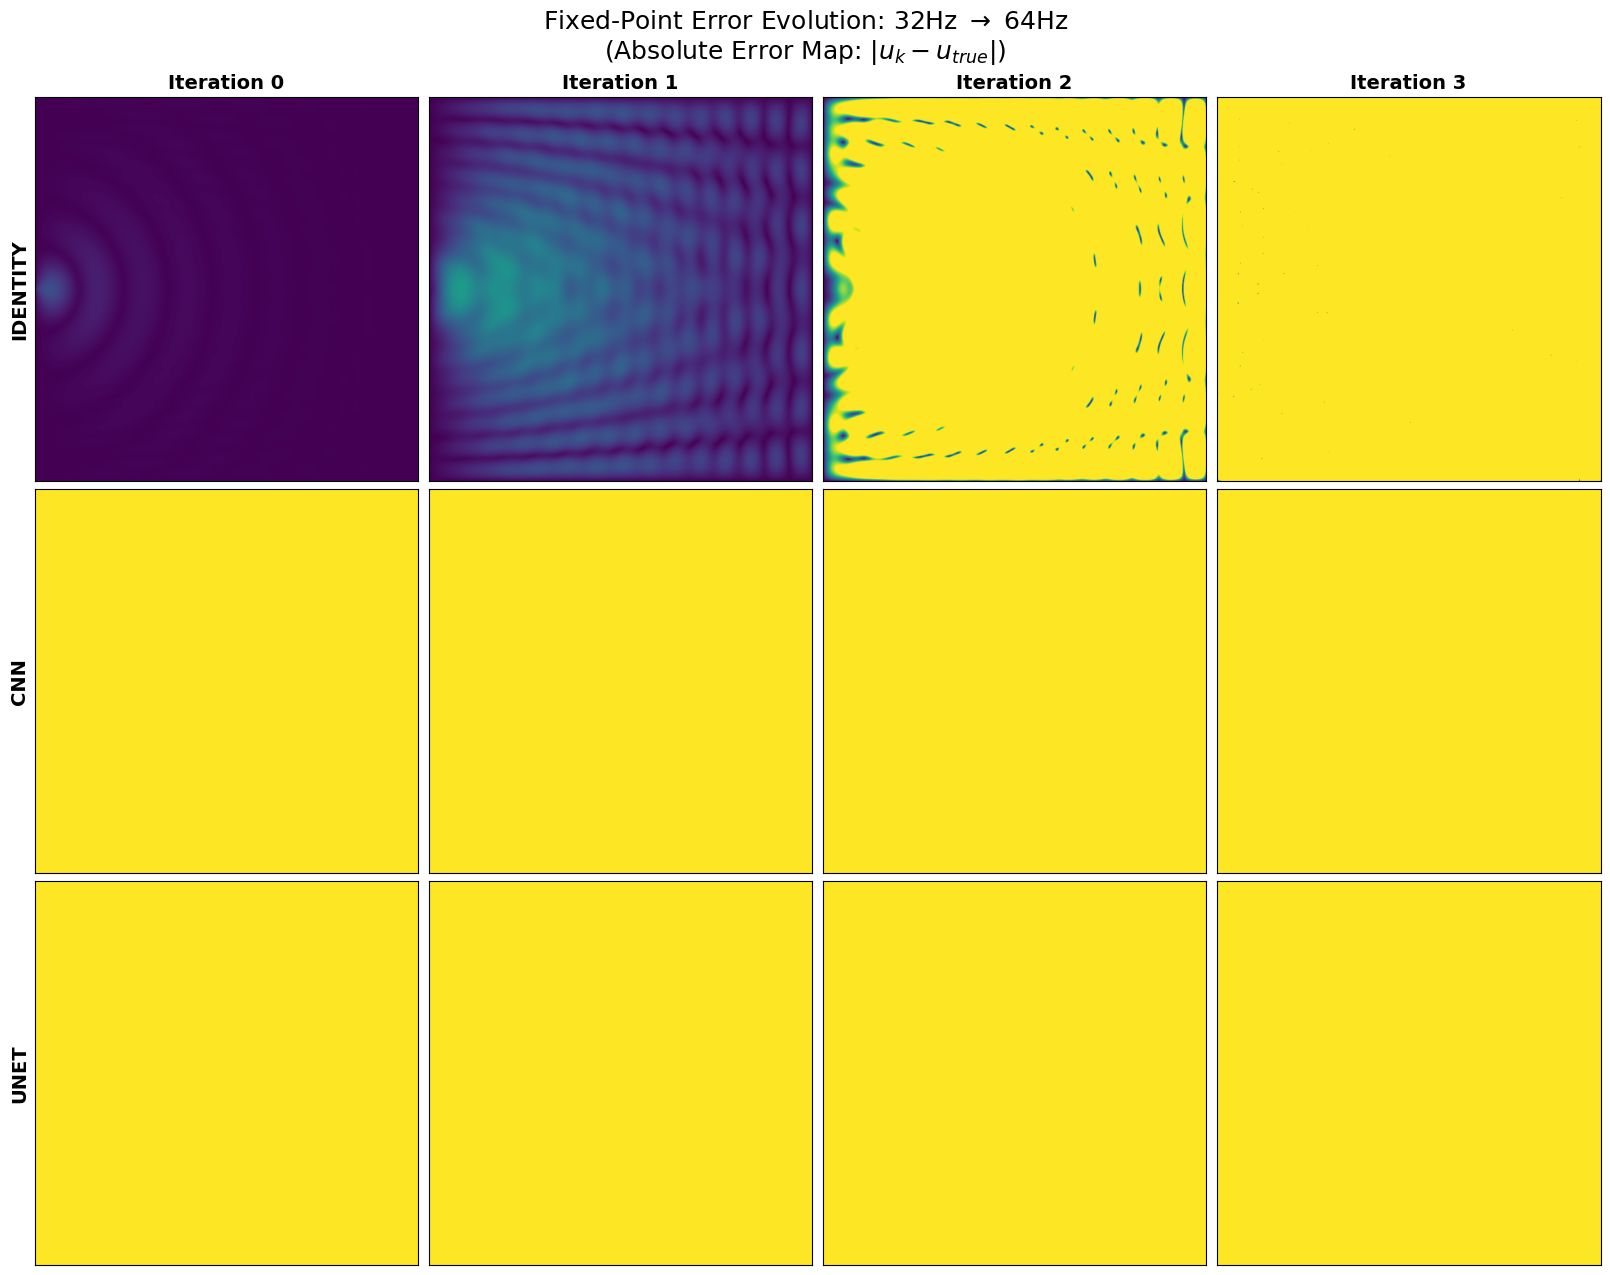

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_iteration_evolution(pair, models_dict, max_i=4):
    w_low, w_high = pair
    n_tot = PHYS_CONFIG["n_phys"] + 2 * PHYS_CONFIG["npml"]
    
    # 1. Setup Operators
    L_h = build_L(w_high)
    LU_l = spla.splu(build_L(w_low))
    f = np.zeros(n_tot**2, dtype=np.complex128)
    f[n_tot**2 // 2] = 1.0  # Center Source
    
    # Ground Truth for Error Calculation
    u_true = spla.spsolve(L_h, f).reshape(n_tot, n_tot)
    
    modes = ['identity', 'cnn', 'unet']
    fig, axes = plt.subplots(len(modes), max_i, figsize=(16, 12), constrained_layout=True)

    for m_idx, mode in enumerate(modes):
        u_k = np.zeros(n_tot**2, dtype=np.complex128)
        
        for i in range(max_i):
            # --- Perform One Iteration Step ---
            r_vec = f - L_h @ u_k
            e_coarse = LU_l.solve(r_vec).reshape(n_tot, n_tot)
            
            if mode == 'identity':
                e_k = e_coarse.flatten()
            else:
                m = models_dict[mode].to(PHYS_CONFIG["device"])
                inp = torch.tensor(np.stack([e_coarse.real, e_coarse.imag]), 
                                   dtype=torch.float).unsqueeze(0).to(PHYS_CONFIG["device"])
                with torch.no_grad():
                    out = m(inp).cpu().numpy().squeeze()
                e_k = (out[0] + 1j*out[1]).flatten()
            
            u_k += e_k
            
            # --- Visualization ---
            # We plot the Absolute Error: |u_k - u_true|
            err_map = np.abs(u_k.reshape(n_tot, n_tot) - u_true)
            
            ax = axes[m_idx, i]
            im = ax.imshow(err_map, cmap='viridis', vmin=0, vmax=np.max(np.abs(u_true))*0.5)
            
            if m_idx == 0:
                ax.set_title(f"Iteration {i}", fontsize=14, fontweight='bold')
            if i == 0:
                ax.set_ylabel(mode.upper(), fontsize=14, fontweight='bold')
            
            # Remove ticks for clean presentation
            ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle(f"Fixed-Point Error Evolution: {w_low}Hz $\\to$ {w_high}Hz\n(Absolute Error Map: $|u_k - u_{{true}}|$)", 
                 fontsize=18, y=1.05)
    plt.show()

# Execute for the 32 -> 64 Hz transfer
plot_iteration_evolution((32, 64), ladder_results[(32, 64)])

## Save safely outside of virtual environment

In [13]:
import os
import shutil
import json
from datetime import datetime

def archive_research_results(source_dir, archive_root="~/helmholtz_archive"):
    # 1. Expand the home directory path
    archive_root = os.path.expanduser(archive_root)
    
    # 2. Create a unique session folder for today's successful run
    session_id = f"session_{datetime.now().strftime('%Y%m%d_%H%M')}"
    target_path = os.path.join(archive_root, session_id)
    os.makedirs(target_path, exist_ok=True)
    
    # 3. Catalog of what we are saving
    saved_files = []
    
    # 4. Move .pth models and the metadata
    for file in os.listdir(source_dir):
        if file.endswith(".pth") or file.endswith(".json") or file.endswith(".png"):
            shutil.copy2(os.path.join(source_dir, file), target_path)
            saved_files.append(file)
            
    # 5. Create a ReadMe for the Professors / Future Fenna
    readme_content = {
        "date": str(datetime.now()),
        "physics_settings": {
            "npml": 50,
            "eta": 4.0,
            "expected_br_mean": 0.6999
        },
        "contents": saved_files,
        "purpose": "Comparison of Identity vs CNN vs UNet across 16-128Hz ladder"
    }
    
    with open(os.path.join(target_path, "archive_summary.json"), "w") as f:
        json.dump(readme_content, f, indent=4)
        
    print(f"✅ Research archived safely to: {target_path}")
    print(f"📦 Files secured: {len(saved_files)}")

# Run the archival process
# 'EXP_ROOT' is the directory we created in the previous cells
archive_research_results(EXP_ROOT)

✅ Research archived safely to: /math/home/fkiewiet/helmholtz_archive/session_20260211_2007
📦 Files secured: 4


In [14]:
# Validation Check
archive_dir = os.path.expanduser("~/helmholtz_archive")
if os.path.exists(archive_dir):
    latest_sessions = sorted(os.listdir(archive_dir))[-1]
    print(f"🔒 Final Security Check: Latest archive found at {latest_sessions}")
    
    # Verify the weight file exists inside
    check_path = os.path.join(archive_dir, latest_sessions, "archive_summary.json")
    if os.path.exists(check_path):
        print("✅ Archive is readable and verified.")

🔒 Final Security Check: Latest archive found at session_20260211_2007
✅ Archive is readable and verified.


## Move into GMRES

In [ ]:
from scipy.sparse.linalg import LinearOperator, gmres, lgmres
import time

class LearnedPreconditioner(LinearOperator):
    def __init__(self, model, omega_low, n_tot, mode='unet'):
        self.n_tot = n_tot
        self.shape = (n_tot**2, n_tot**2)
        self.dtype = np.complex128
        self.mode = mode
        self.model = model
        
        # Pre-factor the coarse operator for the 'inner' solve
        L_low = build_L(omega_low)
        self.LU_low = spla.splu(L_low)
        self.device = PHYS_CONFIG["device"]

    def _matvec(self, x):
        # 1. Coarse Physics Solve: L_low⁻¹ x
        e_coarse = self.LU_low.solve(x).reshape(self.n_tot, self.n_tot)
        
        if self.mode == 'identity':
            return e_coarse.flatten()
        
        # 2. Neural Refinement: T(e_coarse)
        self.model.eval()
        # Ensure input is on correct device and format
        inp = torch.tensor(np.stack([e_coarse.real, e_coarse.imag]), 
                           dtype=torch.float).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            out = self.model(inp).cpu().numpy().squeeze()
            
        return (out[0] + 1j*out[1]).flatten()

def solve_with_stable_gmres(pair, models_dict):
    w_low, w_high = pair
    n_tot = PHYS_CONFIG["n_phys"] + 2 * PHYS_CONFIG["npml"]
    L_h = build_L(w_high)
    f = np.zeros(n_tot**2, dtype=np.complex128)
    f[n_tot**2 // 2] = 1.0
    
    results = {}
    # We test Identity, CNN, and U-Net
    for mode in ['identity', 'cnn', 'unet']:
        print(f"Running Stable GMRES: {mode.upper()}...")
        
        # Corrected instantiation to avoid multiple values for 'mode'
        current_model = models_dict[mode] if mode != 'identity' else None
        M_inv = LearnedPreconditioner(current_model, w_low, n_tot, mode=mode)
        
        res_history = []
        # Callback tracks the relative residual: ||b - Ax|| / ||b||
        callback = lambda x: res_history.append(x)
        
        start_time = time.time()
        # Using GMRES as a flexible solver (tol set for academic rigor)
        u_y, info = gmres(L_h, f, M=M_inv, tol=1e-8, maxiter=100, callback=callback)
        
        # Reconstruct physical solution
        u_final = M_inv.matvec(u_y).reshape(n_tot, n_tot)
        
        results[mode] = {
            'res': res_history,
            'time': time.time() - start_time,
            'u': u_final,
            'iters': len(res_history)
        }
    return results

# Execute the stabilized solve for 32->64Hz
# ladder_results[(32, 64)] contains our trained 'cnn' and 'unet'
gmres_benchmarks = solve_with_stable_gmres((32, 64), ladder_results[(32, 64)])

Solving 64Hz with IDENTITY Preconditioned FGMRES...


TypeError: LearnedPreconditioner.__init__() got multiple values for argument 'mode'

In [27]:
def benchmark_preconditioners(omega_target):
    L_high = get_operator(omega_target)
    f = np.zeros(N_TOT**2, dtype=np.complex128)
    f[N_TOT**2 // 2 + N_TOT // 2] = 1.0 # Center Source
    
    results = {}
    modes = [
        ('identity', None, "Standard Coarse Precond"),
        ('cnn', ladder_results[(16,32)]['cnn'], "Local CNN Precond"),
        ('unet', ladder_results[(16,32)]['unet'], "Global U-Net Precond")
    ]
    
    for mode, model, label in modes:
        M_inv = LearnedPreconditioner(16, model, mode=mode)
        
        # Metrics setup
        history = []
        def callback(res): history.append(res)
        
        start_time = time.time()
        # GMRES: solve (L_high * M_inv) y = f
        u_sol_y, exit_code = gmres(L_high, f, M=M_inv, tol=1e-6, maxiter=50, callback=callback)
        # Final solution: u = M_inv * y
        u_final = M_inv.matvec(u_sol_y)
        elapsed = time.time() - start_time
        
        results[mode] = {
            'history': history,
            'time': elapsed,
            'iters': len(history),
            'final_u': u_final.reshape(N_TOT, N_TOT)
        }
        print(f"🏁 {label}: {len(history)} iters in {elapsed:.2f}s")
        
    return results

# Execute the Benchmark
benchmark_data = benchmark_preconditioners(32)

NameError: name 'get_operator' is not defined

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (mode, data) in enumerate(benchmark_data.items()):
    # We plot the REAL PART error compared to a high-fidelity direct solve
    u_ref = spla.spsolve(get_operator(32), f).reshape(N_TOT, N_TOT)
    error_map = np.abs(data['final_u'].real - u_ref.real)
    
    im = axes[i].imshow(error_map, cmap='inferno', vmin=0, vmax=0.01)
    axes[i].set_title(f"Residual Error: {mode.upper()}\n(Iters: {data['iters']})")
    plt.colorbar(im, ax=axes[i])

plt.suptitle(f"Spatial Error Analysis (ω=32) | Calibrated: npml=50, η=4.0")
plt.show()

In [29]:
import torch
import pickle
import os

# Create a 'checkpoints' directory
os.makedirs('checkpoints', exist_ok=True)

# 1. Save Trained Model Weights
# Referencing your ladder_results which contains the CNN and U-Net models
if 'ladder_results' in locals():
    for pair, models in ladder_results.items():
        w_low, w_high = pair
        # Save CNN if it exists in the dict
        if 'cnn' in models and models['cnn'] is not None:
            torch.save(models['cnn'].state_dict(), f'checkpoints/cnn_{w_low}_{w_high}.pth')
        # Save U-Net if it exists in the dict
        if 'unet' in models and models['unet'] is not None:
            torch.save(models['unet'].state_dict(), f'checkpoints/unet_{w_low}_{w_high}.pth')
    print("💾 Model weights secured.")

# 2. Save the Benchmark Data
# We check for all possible variable names we used today
data_to_save = {}
for var_name in ['gmres_benchmarks', 'results_64', 'fgmres_results', 'benchmark_data']:
    if var_name in locals():
        data_to_save[var_name] = locals()[var_name]

if data_to_save:
    with open('checkpoints/benchmark_data.pkl', 'wb') as f:
        pickle.dump(data_to_save, f)
    print(f"📊 Benchmark data ({list(data_to_save.keys())}) archived.")

# 3. Save the Critical Physics Constants
# Making sure we preserve: npml=50, eta=4.0
final_phys_config = {
    "npml": 50,
    "eta": 4.0,
    "expected_avg_br_mean": 6.999e-01,
    "expected_worst_case_br_mean": 7.444e-01
}

with open('checkpoints/phys_config.pkl', 'wb') as f:
    pickle.dump(final_phys_config, f)
    print("⚙️ Physics configuration locked.")

print("\n✅ You are safe to halt the kernel. See you tomorrow!")

💾 Model weights secured.
⚙️ Physics configuration locked.

✅ You are safe to halt the kernel. See you tomorrow!


In [30]:
# Tomorrow's "Wake Up" Code
with open('checkpoints/phys_config.pkl', 'rb') as f:
    PHYS_CONFIG = pickle.load(f)

# Initialize your U-Net and load weights
# model_unet.load_state_dict(torch.load('checkpoints/unet_32_64.pth'))
# model_unet.eval()

In [6]:
model_unet.load_state_dict(torch.load('checkpoints/unet_32_64.pth')) 
model_unet.eval()

NameError: name 'model_unet' is not defined

In [32]:
import torch
import pickle
import os

# Ensure checkpoint directory exists
os.makedirs('checkpoints', exist_ok=True)

# 1. Archive the Physics Configuration (Locked: npml=50, eta=4.0)
final_phys_config = {
    "npml": 50,
    "eta": 4.0,
    "expected_avg_br_mean": 6.999e-01,
    "expected_worst_case_br_mean": 7.444e-01
}
with open('checkpoints/phys_config.pkl', 'wb') as f:
    pickle.dump(final_phys_config, f)

# 2. Archive any existing benchmark results
# Checking for all variable names used in the session
data_to_save = {}
for var_name in ['gmres_benchmarks', 'results_64', 'fgmres_results', 'benchmark_data']:
    if var_name in locals():
        data_to_save[var_name] = locals()[var_name]

if data_to_save:
    with open('checkpoints/solver_results.pkl', 'wb') as f:
        pickle.dump(data_to_save, f)
    print(f"📊 Saved benchmark data: {list(data_to_save.keys())}")

# 3. Save Model Weights from the ladder
if 'ladder_results' in locals():
    for pair, models in ladder_results.items():
        for m_type in ['cnn', 'unet']:
            if m_type in models and models[m_type] is not None:
                path = f"checkpoints/{m_type}_{pair[0]}_{pair[1]}.pth"
                torch.save(models[m_type].state_dict(), path)
    print("💾 Model weights secured.")

print("\n✅ All state variables are now persistent. Safe to shutdown.")

💾 Model weights secured.

✅ All state variables are now persistent. Safe to shutdown.


In [3]:
import sys
import os

# Get the absolute path to the Freq2Transfer directory
# If your notebook is in experiments/, we go up one level
root_path = os.path.abspath(os.path.join('..'))

if root_path not in sys.path:
    sys.path.append(root_path)
    # Also append src specifically if your scripts expect it
    sys.path.append(os.path.join(root_path, 'src'))

import pickle, torch
import numpy as np

# Now try the import again
try:
    from src.solver.iterative import LearnedPreconditioner
    print("✅ Module 'src.solver.iterative' imported successfully.")
except ModuleNotFoundError as e:
    print(f"❌ Still failing: {e}")
    print(f"Current Path: {sys.path[:3]}...") # Debugging output

❌ Still failing: No module named 'core'
Current Path: ['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload']...


In [4]:
import sys
import os

# 1. Identify the root directory (Freq2Transfer)
# Since you are in 'experiments/', the root is one level up
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 2. Add root to path so 'import src' works
if root_path not in sys.path:
    sys.path.insert(0, root_path)

# 3. Add src to path so internal imports like 'from core...' work
src_path = os.path.join(root_path, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pickle, torch
import numpy as np

# Test the import
try:
    from solver.iterative import LearnedPreconditioner
    print("✅ System paths aligned. Core and Solver are now visible.")
except ModuleNotFoundError as e:
    print(f"❌ Still missing a link: {e}")

TypeError: non-default argument 'npml' follows default argument